# `comp/` バンド比較

`T3/**/bands/comp/` 内の信頼バンド JSON を読み込み、同じ (scenario, index) について
**3方式**を比較する:

- **standard (fixed B)** — 背景をノミナル値に固定した通常フィット (`band_..._idxNNN.json`)
- **varied B (Gaussian)** — 背景を `Normal(B, sqrt(B))` で独立に揺らす新方式 (`..._bkgpen.json`)
- **penalty (beta, old)** — 旧ベータ比 + プロファイル方式 (`..._bkgpen_beta.json`)

各 CL (0.678 / 0.954) でバンド幅とその standard 比、区間プロットを出す。
このノートブックは `1eV/` ディレクトリから実行する想定。


In [16]:
import glob, json, os, re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

ROOT     = 'T3'        # search ROOT/**/bands/comp/*.json
NORM     = 1e12        # plot flux in units of 1e12 cm^-2 s^-1
N_PARAM  = 180         # flux parameters -> energy grid eb = linspace(0.18, 2, N)
EB       = np.linspace(0.18, 2, N_PARAM)

# scenario display names
SCEN_LABEL = {'a': 'No Bkg', 'b': 'Exp Bkg'}
def scen_name(s):
    return SCEN_LABEL.get(s, f'bkg {s}')

# filename suffix after idxNNN -> (label, draw order, colour)
VARIANTS = {
    '':             ('standard (fixed B)',   0, 'C0'),
    '_bkgpen_beta': ('penalty (beta, old)',  1, 'C2'),
    '_bkgpen':      ('varied B (Gaussian)',  2, 'C3'),
}
_RE = re.compile(r'band_bkg(?P<scen>[A-Za-z0-9]+)_idx(?P<idx>\d+)'
                 r'(?P<suf>(?:_bkgpen(?:_beta)?)?)\.json$')

def load_one(path):
    with open(path) as f:
        o = json.load(f)
    m = _RE.search(os.path.basename(path))
    suf = m.group('suf') if m else ''
    label, order, color = VARIANTS.get(suf, (suf or 'unknown', 9, 'C7'))
    o['variant'] = label
    o['_order']  = order
    o['_color']  = color
    o['band_physical'] = {float(k): v for k, v in o['band_physical'].items()}
    return o

files = sorted(glob.glob(os.path.join(ROOT, '**', 'bands', 'comp', '*.json'),
                         recursive=True))
bands = [load_one(p) for p in files]
print(f'loaded {len(bands)} band file(s) from {ROOT}/**/bands/comp/')
for b in sorted(bands, key=lambda b: (b['background_scenario'], b['index'], b['_order'])):
    print(f"  scen={b['background_scenario']:>4}  idx={b['index']:>3}  {b['variant']}")


loaded 6 band file(s) from T3/**/bands/comp/
  scen=   a  idx= 40  standard (fixed B)
  scen=   a  idx= 40  penalty (beta, old)
  scen=   a  idx= 40  varied B (Gaussian)
  scen=   b  idx= 40  standard (fixed B)
  scen=   b  idx= 40  penalty (beta, old)
  scen=   b  idx= 40  varied B (Gaussian)


In [17]:
# tidy table: one row per (scenario, index, level, variant)
rows = []
for b in bands:
    scen, idx = b['background_scenario'], b['index']
    for lv, (lo, hi) in b['band_physical'].items():
        rows.append(dict(scenario=scen, index=idx, E_MeV=EB[idx],
                         level=lv, variant=b['variant'], order=b['_order'],
                         lower=lo, upper=hi, width=hi - lo,
                         best_fit=b['best_fit_physical']))
df = pd.DataFrame(rows).sort_values(['scenario', 'index', 'level', 'order'])

show = ['scenario', 'index', 'E_MeV', 'level', 'variant', 'lower', 'upper', 'width', 'best_fit']
disp = df[show].copy()
disp['scenario'] = disp['scenario'].map(scen_name)
for c in ['lower', 'upper', 'width', 'best_fit']:
    disp[c] = disp[c] / NORM
disp.round(4)


,scenario,index,E_MeV,level,variant,lower,upper,width,best_fit
0,a,40,0.5867,0.678,standard (fixed B),0.7376,1.1348,0.3972,0.9624
4,a,40,0.5867,0.678,"penalty (beta, old)",0.7191,1.1348,0.4156,0.9624
2,a,40,0.5867,0.678,varied B (Gaussian),0.7191,1.1348,0.4156,0.9624
1,a,40,0.5867,0.954,standard (fixed B),0.6836,1.1938,0.5102,0.9624
5,a,40,0.5867,0.954,"penalty (beta, old)",0.6665,1.2244,0.5579,0.9624
3,a,40,0.5867,0.954,varied B (Gaussian),0.6498,1.2244,0.5746,0.9624
6,b,40,0.5867,0.678,standard (fixed B),0.7191,1.1639,0.4448,0.9624
10,b,40,0.5867,0.678,"penalty (beta, old)",0.7011,1.1938,0.4926,0.9624
8,b,40,0.5867,0.678,varied B (Gaussian),0.6836,1.1938,0.5102,0.9624
7,b,40,0.5867,0.954,standard (fixed B),0.6336,1.2558,0.6223,0.9624


In [18]:
# band width per variant, and ratio vs the 'standard' variant
piv = df.pivot_table(index=['scenario', 'index', 'level'],
                     columns='variant', values='width')
print('band width  [1e12 cm^-2 s^-1]:')
display((piv / NORM).round(4))

std = next((c for c in piv.columns if c.startswith('standard')), None)
if std is not None:
    print('\nwidth ratio vs standard (>1 = wider):')
    display(piv.div(piv[std], axis=0).round(4))


band width  [1e12 cm^-2 s^-1]:


variant               penalty (beta, old)  standard (fixed B)  \
scenario index level                                            
a        40    0.678               0.4156              0.3972   
               0.954               0.5579              0.5102   
b        40    0.678               0.4926              0.4448   
               0.954               0.7189              0.6223   

variant               varied B (Gaussian)  
scenario index level                       
a        40    0.678               0.4156  
               0.954               0.5746  
b        40    0.678               0.5102  
               0.954               0.7189


width ratio vs standard (>1 = wider):


variant               penalty (beta, old)  standard (fixed B)  \
scenario index level                                            
a        40    0.678               1.0465                 1.0   
               0.954               1.0936                 1.0   
b        40    0.678               1.1076                 1.0   
               0.954               1.1552                 1.0   

variant               varied B (Gaussian)  
scenario index level                       
a        40    0.678               1.0465  
               0.954               1.1263  
b        40    0.678               1.1471  
               0.954               1.1552

saved comp_bands_level0.678.pdf


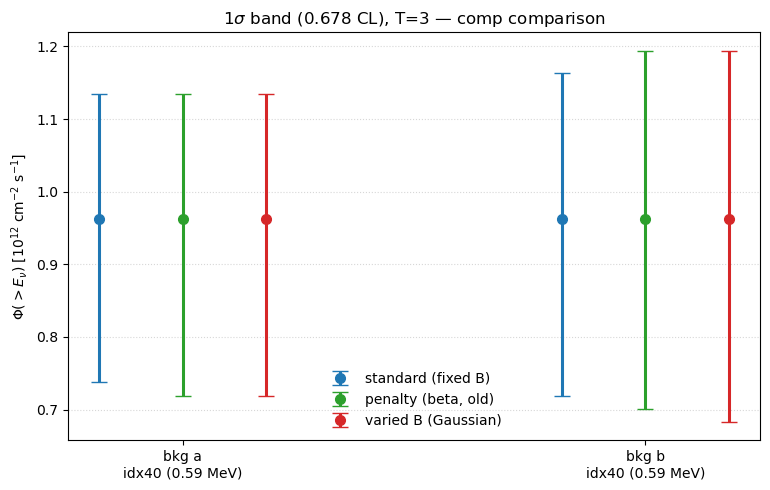

saved comp_bands_level0.954.pdf


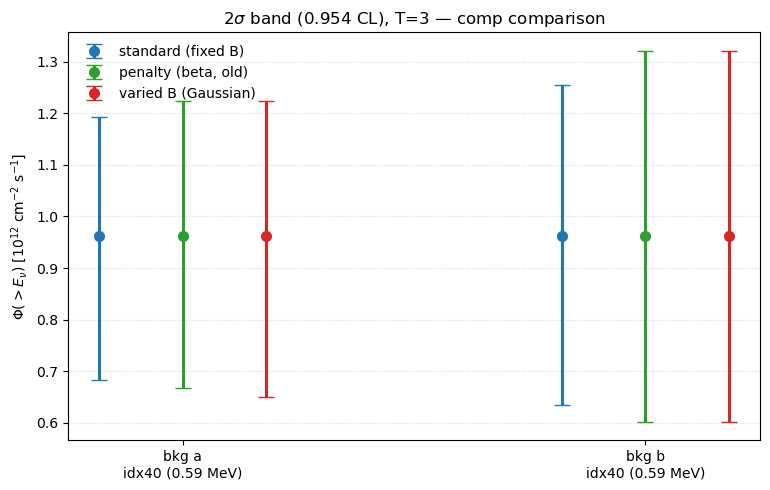

In [19]:
# interval comparison: one figure per confidence level
levels  = sorted(df['level'].unique())
groups  = sorted(df.groupby(['scenario', 'index']).groups.keys())
glabels = [f'{scen_name(s)}\nidx{ix} ({EB[ix]:.2f} MeV)' for s, ix in groups]
variants = [v for _, v in sorted({(b['_order'], b['variant']) for b in bands})]
vcolor   = {b['variant']: b['_color'] for b in bands}
nv = len(variants)

for lv in levels:
    fig, ax = plt.subplots(figsize=(2.4 * len(groups) + 3, 5))
    for vi, var in enumerate(variants):
        xs, los, his, cen = [], [], [], []
        for gi, (s, ix) in enumerate(groups):
            sub = df[(df.scenario == s) & (df['index'] == ix) &
                     (df.level == lv) & (df.variant == var)]
            if sub.empty:
                continue
            xs.append(gi + (vi - (nv - 1) / 2) * 0.18)
            los.append(sub.lower.iloc[0] / NORM)
            his.append(sub.upper.iloc[0] / NORM)
            cen.append(sub.best_fit.iloc[0] / NORM)
        if not xs:
            continue
        xs, los, his, cen = map(np.array, (xs, los, his, cen))
        ax.errorbar(xs, cen, yerr=[cen - los, his - cen], fmt='o', ms=7,
                    capsize=6, lw=2.2, color=vcolor.get(var, 'C7'), label=var)
    ax.set_xticks(range(len(groups)))
    ax.set_xticklabels(glabels)
    ax.set_ylabel(r'$\Phi(>E_\nu)$ [$10^{12}$ cm$^{-2}$ s$^{-1}$]')
    nsig = '2' if lv > 0.9 else ('1' if abs(lv - 0.678) < 0.05 else f'{lv:.3f}')
    ax.set_title(rf'{nsig}$\sigma$ band ({lv:.3f} CL), T=3 — comp comparison')
    ax.legend(frameon=False)
    ax.grid(axis='y', ls=':', alpha=0.5)
    fig.tight_layout()
    out = f'comp_bands_level{lv:.3f}.pdf'
    fig.savefig(out)
    print('saved', out)
    plt.show()


saved comp_bands_1and2sigma.pdf


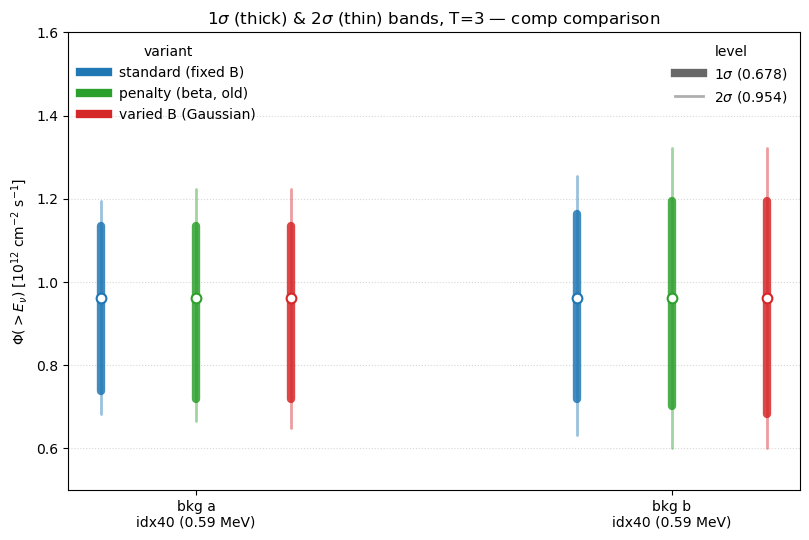

In [24]:
# 1σ と 2σ を1枚に重ねる (2σ = 細/外側, 1σ = 太/内側, 中央=best-fit)
from matplotlib.lines import Line2D

groups  = sorted(df.groupby(['scenario', 'index']).groups.keys())
glabels = [f'{scen_name(s)}\nidx{ix} ({EB[ix]:.2f} MeV)' for s, ix in groups]
variants = [v for _, v in sorted({(b['_order'], b['variant']) for b in bands})]
vcolor   = {b['variant']: b['_color'] for b in bands}
nv = len(variants)
levels = sorted(df['level'].unique())
L1, L2 = levels[0], levels[-1]      # 1σ (narrow CL), 2σ (wide CL)

def interval(s, ix, lv, var):
    sub = df[(df.scenario == s) & (df['index'] == ix) &
             (df.level == lv) & (df.variant == var)]
    if sub.empty:
        return None
    return sub.lower.iloc[0] / NORM, sub.upper.iloc[0] / NORM, sub.best_fit.iloc[0] / NORM

fig, ax = plt.subplots(figsize=(2.6 * len(groups) + 3, 5.5))
for vi, var in enumerate(variants):
    col = vcolor.get(var, 'C7')
    for gi, (s, ix) in enumerate(groups):
        x = gi + (vi - (nv - 1) / 2) * 0.20
        i2, i1 = interval(s, ix, L2, var), interval(s, ix, L1, var)
        if i2:
            ax.plot([x, x], i2[:2], color=col, lw=2.0, alpha=0.45,
                    solid_capstyle='round')
        if i1:
            ax.plot([x, x], i1[:2], color=col, lw=6.0, alpha=0.85,
                    solid_capstyle='round')
        ref = i1 or i2
        if ref:
            ax.plot([x], [ref[2]], 'o', color='white', mec=col, mew=1.5,
                    ms=7, zorder=5)

# two legends: colour = variant, line width = confidence level
var_h = [Line2D([0], [0], color=vcolor.get(v, 'C7'), lw=6) for v in variants]
lvl_h = [Line2D([0], [0], color='0.3', lw=6, alpha=0.85),
         Line2D([0], [0], color='0.3', lw=2, alpha=0.45)]
leg1 = ax.legend(var_h, variants, title='variant', frameon=False, loc='upper left')
ax.add_artist(leg1)
ax.legend(lvl_h, [f'1$\\sigma$ ({L1:.3f})', f'2$\\sigma$ ({L2:.3f})'],
          title='level', frameon=False, loc='upper right')

ax.set_ylim(0.5, 1.6)
ax.set_xticks(range(len(groups)))
ax.set_xticklabels(glabels)
ax.set_ylabel(r'$\Phi(>E_\nu)$ [$10^{12}$ cm$^{-2}$ s$^{-1}$]')
ax.set_title(r'1$\sigma$ (thick) & 2$\sigma$ (thin) bands, T=3 — comp comparison')
ax.grid(axis='y', ls=':', alpha=0.5)
fig.tight_layout()
fig.savefig('comp_bands_1and2sigma.pdf')
print('saved comp_bands_1and2sigma.pdf')
plt.show()
